# 📊 Modelagem - OLS

Este notebook utiliza a base tratada salva em `data/processed/credit_processed.csv`
para construir um modelo OLS com foco em interpretação estatística.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
DATA_PATH = Path("../data/processed/credit_processed.csv")
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(400, 14)


,Income,Limit,Rating,Cards,Age,Education,Balance,debt_to_income,cards_per_age,Gender_Female,Student_Yes,Married_Yes,Ethnicity_Asian,Ethnicity_Caucasian
0,14.891,3606,283,2,34,11,333,20.955258,0.057143,False,False,True,False,True
1,106.025,6645,483,3,82,15,903,8.437281,0.036145,True,True,True,True,False
2,104.593,7075,514,4,71,11,580,5.492788,0.055556,False,False,False,True,False
3,148.924,9504,681,3,36,11,964,6.429924,0.081081,True,False,False,True,False
4,55.882,4897,357,2,68,16,331,5.819064,0.028986,False,False,True,False,True


## 1. Separação entre features e target

In [3]:
target = "Limit"

X = df.drop(columns=[target])
y = df[target]

print("X:", X.shape)
print("y:", y.shape)

X: (400, 13)
y: (400,)


## 2. Split treino e teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## 3. Ajuste do modelo OLS

In [5]:
X_train_ols = X_train.copy()
X_test_ols = X_test.copy()

# transforma bool em int
bool_cols_train = X_train_ols.select_dtypes(include=["bool"]).columns
bool_cols_test = X_test_ols.select_dtypes(include=["bool"]).columns

X_train_ols[bool_cols_train] = X_train_ols[bool_cols_train].astype(int)
X_test_ols[bool_cols_test] = X_test_ols[bool_cols_test].astype(int)

# garante tudo numérico
X_train_ols = X_train_ols.apply(pd.to_numeric)
X_test_ols = X_test_ols.apply(pd.to_numeric)

# adiciona constante
X_train_const = sm.add_constant(X_train_ols, has_constant="add")
X_test_const = sm.add_constant(X_test_ols, has_constant="add")

# modelo
model_ols = sm.OLS(y_train, X_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  Limit   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     6002.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:03:38   Log-Likelihood:                -1918.1
No. Observations:                 300   AIC:                             3864.
Df Residuals:                     286   BIC:                             3916.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -102.9818    

## 4. Predições e métricas

In [6]:
y_pred_train = model_ols.predict(X_train_const)
y_pred_test = model_ols.predict(X_test_const)

def regression_metrics(y_true, y_pred, label="conjunto"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # R² em teste calculado manualmente a partir da métrica sklearn
    from sklearn.metrics import r2_score
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

regression_metrics(y_train, y_pred_train, "Treino")
regression_metrics(y_test, y_pred_test, "Teste")

Treino -> MAE: 118.0707 | RMSE: 144.7193 | R²: 0.9963
Teste -> MAE: 117.3700 | RMSE: 146.3133 | R²: 0.9947


## 5. Coeficientes e significância

In [7]:
summary_table = pd.DataFrame({
    "feature": model_ols.params.index,
    "coeficiente": model_ols.params.values,
    "p_value": model_ols.pvalues.values
}).sort_values("p_value")

summary_table.head(20)

,feature,coeficiente,p_value
2,Rating,13.202724,2.354094e-115
6,Balance,0.412877,1.192059e-06
10,Student_Yes,-212.327872,7.144499e-06
1,Income,3.567047,7.829115e-05
3,Cards,-54.950842,1.414790e-03
11,Married_Yes,-30.361255,9.074658e-02
12,Ethnicity_Asian,35.616183,1.457611e-01
8,cards_per_age,-1179.834701,1.655642e-01
5,Education,3.254738,2.368122e-01
0,const,-102.981776,2.471346e-01


## 6. Multicolinearidade (VIF)

In [8]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

vif_data.sort_values("VIF", ascending=False).head(20)

,feature,VIF
0,const,107.680297
2,Rating,41.168997
6,Balance,21.048677
1,Income,13.167785
8,cards_per_age,10.634885
3,Cards,7.768521
4,Age,3.957096
7,debt_to_income,3.651647
10,Student_Yes,2.410311
12,Ethnicity_Asian,1.553331


## 7. Gráficos diagnósticos

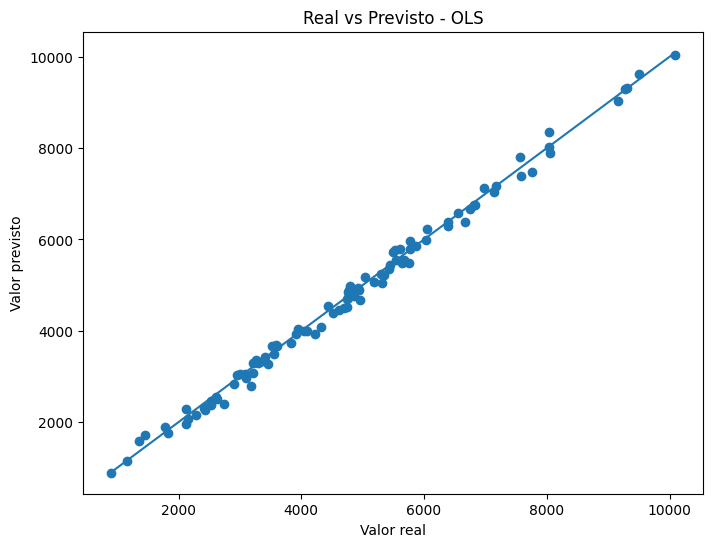

In [9]:
residuos = y_test - y_pred_test

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Real vs Previsto - OLS")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

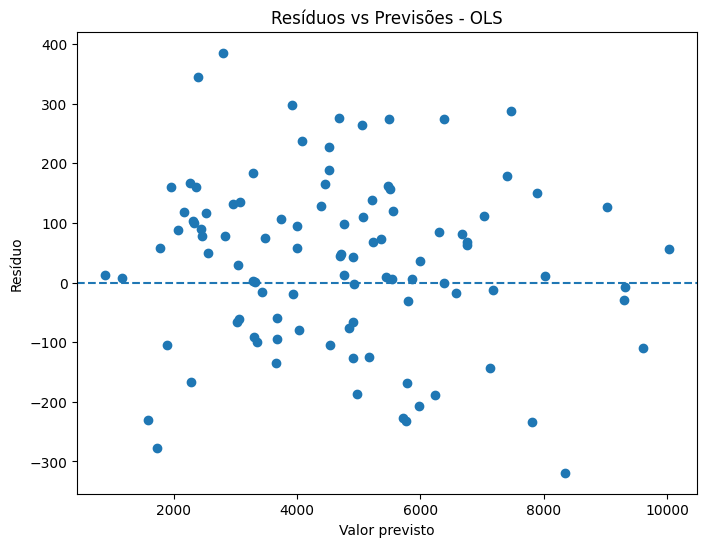

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Valor previsto")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Previsões - OLS")
plt.show()

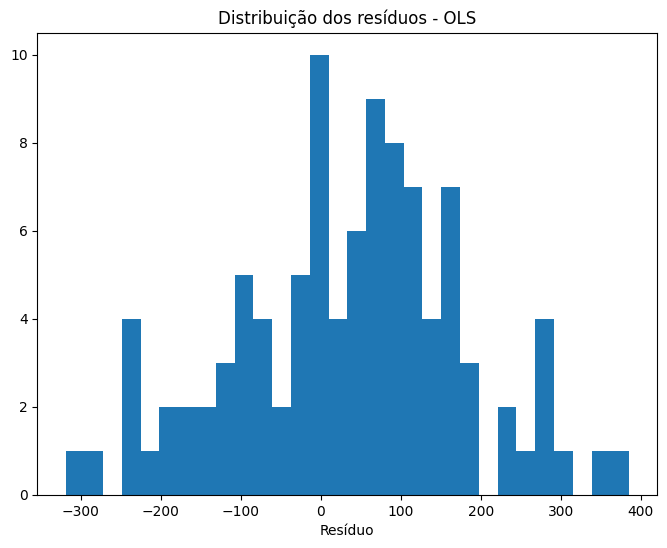

In [11]:
plt.figure(figsize=(8, 6))
plt.hist(residuos, bins=30)
plt.title("Distribuição dos resíduos - OLS")
plt.xlabel("Resíduo")
plt.show()

In [14]:
cols_to_remove = ["Rating", "Balance"]

X = df.drop(columns=["Limit"] + cols_to_remove)
y = df["Limit"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [16]:
import pandas as pd
import numpy as np

# converte bool para int
bool_cols_train = X_train.select_dtypes(include=["bool"]).columns
bool_cols_test = X_test.select_dtypes(include=["bool"]).columns

X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

# garante tudo numérico
X_train = X_train.apply(pd.to_numeric)
X_test = X_test.apply(pd.to_numeric)

print(X_train.dtypes.value_counts())
print(X_test.dtypes.value_counts())

int64      8
float64    3
Name: count, dtype: int64
int64      8
float64    3
Name: count, dtype: int64


In [17]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const = sm.add_constant(X_test, has_constant="add")

In [18]:
model_ols = sm.OLS(y_train, X_train_const).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  Limit   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     196.9
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          6.16e-127
Time:                        23:14:09   Log-Likelihood:                -2438.6
No. Observations:                 300   AIC:                             4901.
Df Residuals:                     288   BIC:                             4946.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1363.8105    

In [19]:
y_pred = model_ols.predict(X_test_const)

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.8513
MAE: 632.1406
RMSE: 776.3235


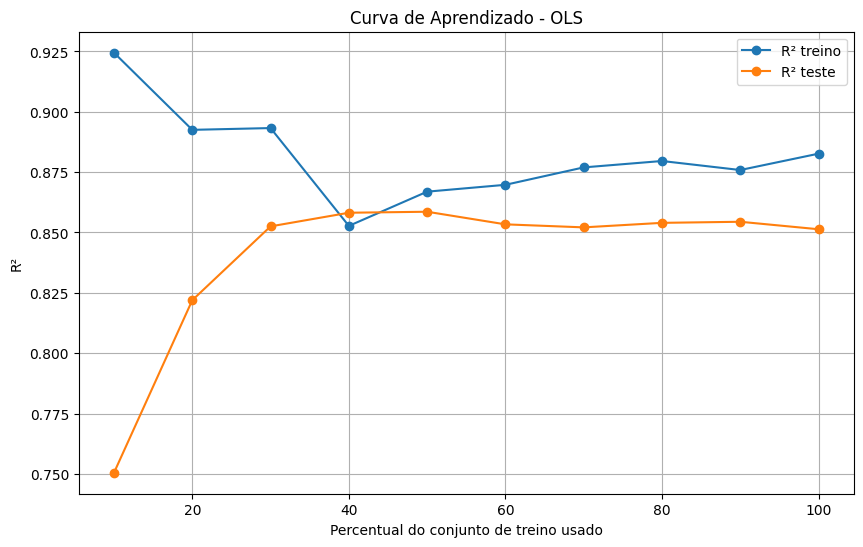

In [21]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

train_sizes = np.linspace(0.1, 1.0, 10)
r2_train_scores = []
r2_test_scores = []

for frac in train_sizes:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train,
            train_size=frac,
            random_state=42
        )
    else:
        X_sub, y_sub = X_train.copy(), y_train.copy()

    X_sub_const = sm.add_constant(X_sub, has_constant="add")
    X_test_const_curve = sm.add_constant(X_test, has_constant="add")

    model_curve = sm.OLS(y_sub, X_sub_const).fit()

    y_sub_pred = model_curve.predict(X_sub_const)
    y_test_pred = model_curve.predict(X_test_const_curve)

    r2_train_scores.append(r2_score(y_sub, y_sub_pred))
    r2_test_scores.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(train_sizes * 100, r2_train_scores, marker="o", label="R² treino")
plt.plot(train_sizes * 100, r2_test_scores, marker="o", label="R² teste")
plt.xlabel("Percentual do conjunto de treino usado")
plt.ylabel("R²")
plt.title("Curva de Aprendizado - OLS")
plt.legend()
plt.grid(True)
plt.show()

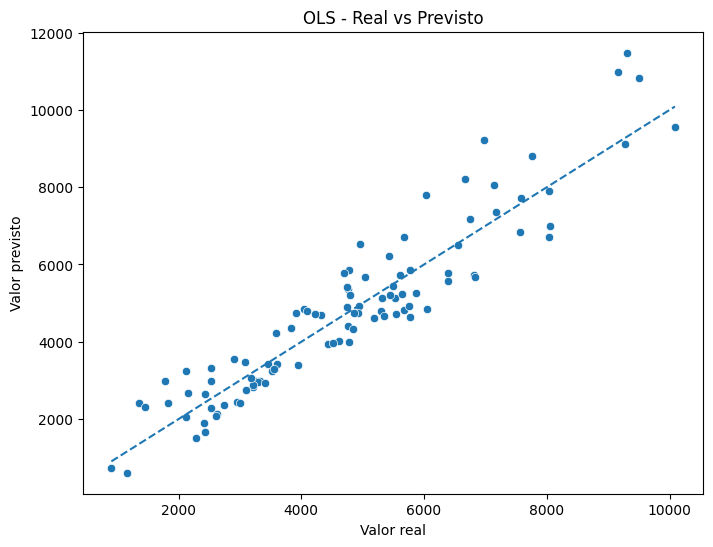

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("OLS - Real vs Previsto")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.show()
